# OBIS Global Spatial and Depth Distribution Analysis

This notebook summarises **family-level taxonomic context**, **geographic occurrence**, and **depth distribution** for a focal fish taxon using OBIS data.

**How to use:** change only the three taxon values in the next cell, then **Run All**. All headings, subtitles, plots, and output-name objects update automatically.

In [30]:
# Define your focal taxon
familyX <- "Channichthyidae"
genusX  <- "Neopagetopsis"
spX     <- "Neopagetopsis ionah"

# Extract species epithet
speciesX <- sub(
  paste0("^", genusX, "\\s+"),
  "",
  spX
)

# Define filename cleaning function
clean_filename <- function(x) {
  gsub("[^A-Za-z0-9]+", "_", x)
}

# Generate output filename
output_basename <- paste(
  clean_filename(familyX),
  clean_filename(genusX),
  clean_filename(speciesX),
  "OBIS_depth_distribution_analysis",
  sep = "_"
)

# Check results
# print(speciesX)
print(output_basename)

[1] "Channichthyidae_Neopagetopsis_ionah_OBIS_depth_distribution_analysis"


In [31]:
# EDIT ONLY THESE THREE VALUES FOR A NEW ANALYSIS
spX     <- "Neopagetopsis ionah"
genusX  <- "Neopagetopsis"
familyX <- "Channichthyidae"

In [32]:
# Packages required by the rendered analysis
required_packages <- c(
  "IRdisplay", "robis", "leaflet", "dplyr",
  "ggplot2", "RColorBrewer", "ggtext"
)

missing_packages <- required_packages[
  !vapply(required_packages, requireNamespace, logical(1), quietly = TRUE)
]

if (length(missing_packages) > 0) {
  stop(
    "Install these packages before running the notebook: ",
    paste(missing_packages, collapse = ", ")
  )
}

# Load packages without displaying startup messages
suppressPackageStartupMessages({
  library(robis)
  library(leaflet)
  library(dplyr)
  library(ggplot2)
  library(RColorBrewer)
  library(ggtext)
})
# ============================================================
# AUTOMATIC ANALYSIS / DOCUMENT NAME
# ============================================================

# Extract species epithet (e.g. "ionah")
speciesX <- sub(
  paste0("^", genusX, "\\s+"),
  "",
  spX
)

# Clean names for use in filenames
clean_name <- function(x) {
  gsub("[^A-Za-z0-9]+", "_", x)
}

# Create unique name for each analysis
analysis_name <- paste(
  clean_name(familyX),
  clean_name(genusX),
  clean_name(speciesX),
  sep = "_"
)

# Create output filename
output_basename <- paste0(
  analysis_name,
  "_OBIS_depth_distribution_analysis"
)

# Check filename
#print(output_basename)
output_basename <- paste0(analysis_name, "_OBIS_depth_distribution_analysis")

# # Dynamic notebook subtitle
# IRdisplay::display_markdown(
#   paste0(
#     "## *", spX, "*\n\n",
#     "**Genus:** *", genusX, "*  \n",
#     "**Family:** ", familyX
#   )
# )

## 1. Taxonomic context

### How species-rich is the focal genus within its family?

The focal genus is highlighted to place the selected taxon in its broader family-level context.

Retrieved 28 records of approximately 28 (100%)

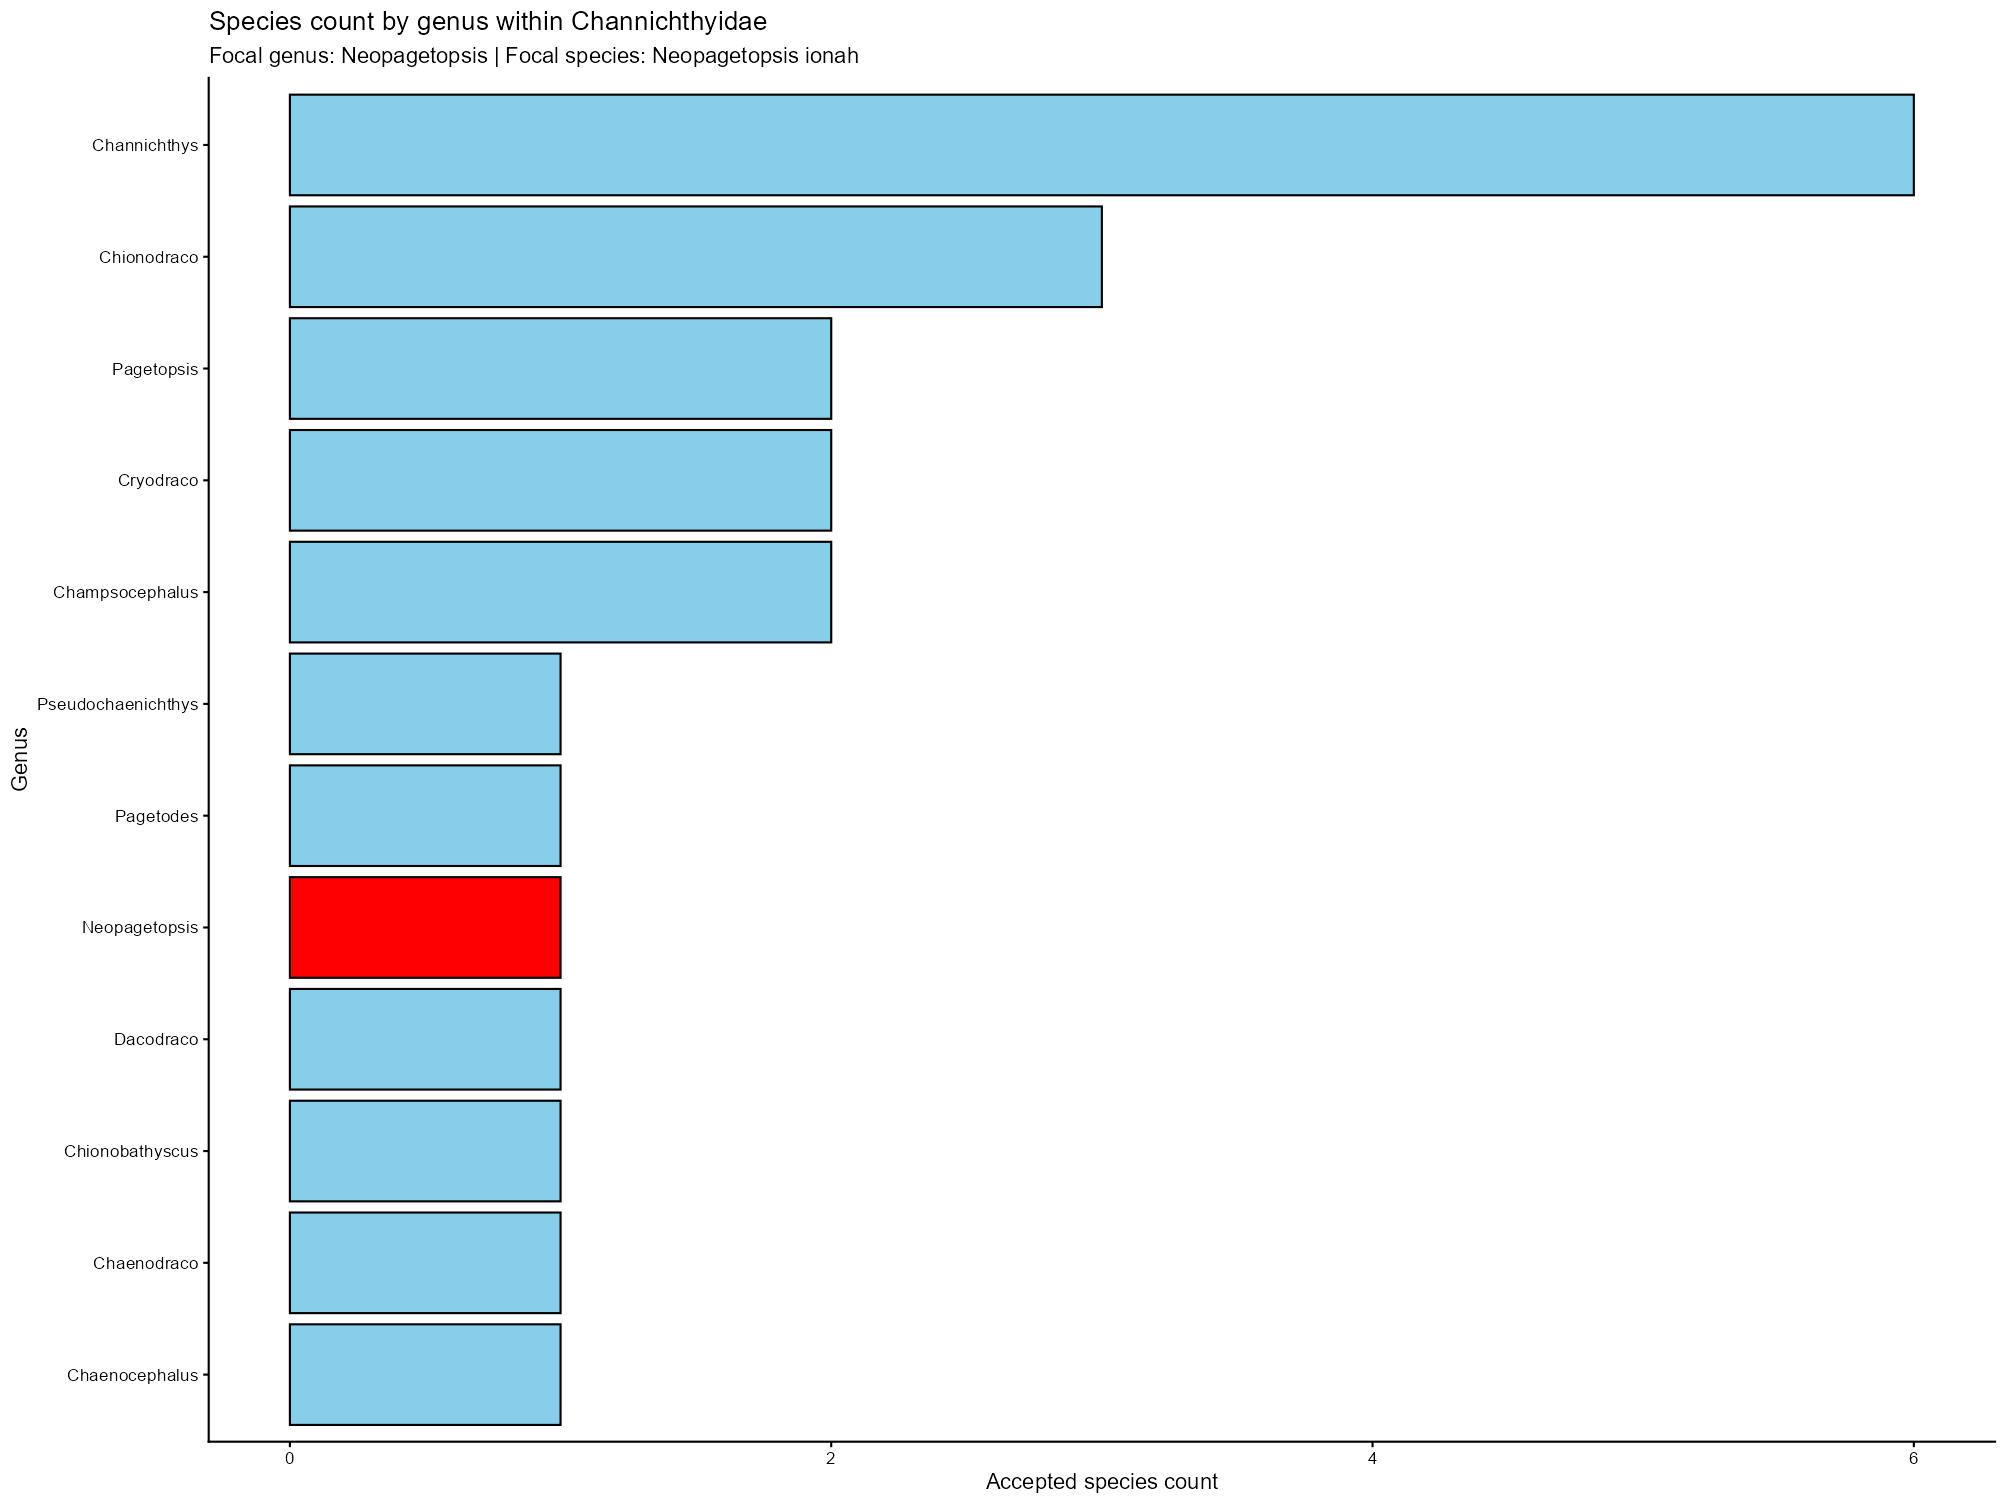

In [33]:
# Retrieve the family checklist and retain accepted species
cl <- checklist(familyX)

cl_filtered <- cl %>%
  filter(
    taxonomicStatus == "accepted",
    taxonRank == "Species",
    !is.na(genus)
  )

# Count accepted species per genus
family_counts <- cl_filtered %>%
  count(genus, name = "species_count") %>%
  arrange(species_count)

# Plot family-level genus richness
p_family <- ggplot(
  family_counts,
  aes(
    x = reorder(genus, species_count),
    y = species_count,
    fill = genus == genusX
  )
) +
  geom_col(color = "black") +
  scale_fill_manual(values = c("TRUE" = "red", "FALSE" = "skyblue")) +
  coord_flip() +
  guides(fill = "none") +
  labs(
    title = paste("Species count by genus within", familyX),
    subtitle = paste("Focal genus:", genusX, "| Focal species:", spX),
    x = "Genus",
    y = "Accepted species count"
  ) +
  theme_classic()

p_family

## 2. OBIS occurrence records

### Where does the focal genus occur, and across what depths?

OBIS occurrence records are retrieved at the **genus level** so that the focal species can be interpreted alongside congeners.

In [34]:
# Download OBIS records for the focal genus
occ <- occurrence(genusX)

# Retain records with depth information for the depth analysis
data_filtered <- occ %>%
  filter(!is.na(depth), !is.na(scientificName)) %>%
  mutate(scientificName = as.character(scientificName))

if (nrow(data_filtered) == 0) {
  stop("No OBIS records with depth values were returned for ", genusX, ".")
}

# Stable species order and shared colour palette
species_names <- sort(unique(data_filtered$scientificName))
my_colors <- colorRampPalette(RColorBrewer::brewer.pal(9, "Set1"))(
  length(species_names)
)
names(my_colors) <- species_names

data_filtered <- data_filtered %>%
  mutate(
    scientificName = factor(scientificName, levels = species_names),
    facet_label = paste0("<b><i>", scientificName, "</i></b>")
  )

Retrieved 212 records of approximately 212 (100%)

## 3. Geographic distribution

### Spatial occurrence records for species within the focal genus

In [35]:
# Use only records with valid coordinates for mapping
map_data <- data_filtered %>%
  filter(!is.na(decimalLongitude), !is.na(decimalLatitude))

if (nrow(map_data) == 0) {
  stop("No mapped OBIS records with valid coordinates were returned for ", genusX, ".")
}

pal <- colorFactor(
  palette = my_colors,
  domain = species_names
)

m <- leaflet(map_data) %>%
  addProviderTiles(providers$Esri.WorldImagery) %>%
  addCircleMarkers(
    lng = ~decimalLongitude,
    lat = ~decimalLatitude,
    color = ~pal(scientificName),
    fillColor = ~pal(scientificName),
    fillOpacity = 0.8,
    stroke = FALSE,
    radius = 5,
    popup = ~as.character(scientificName)
  ) %>%
  addLegend(
    position = "bottomright",
    pal = pal,
    values = species_names,
    title = "Species",
    opacity = 1
  )

m

<leaflet HTML widget>

## 4. Depth distribution

### How are occurrence records distributed across depth within the focal genus?

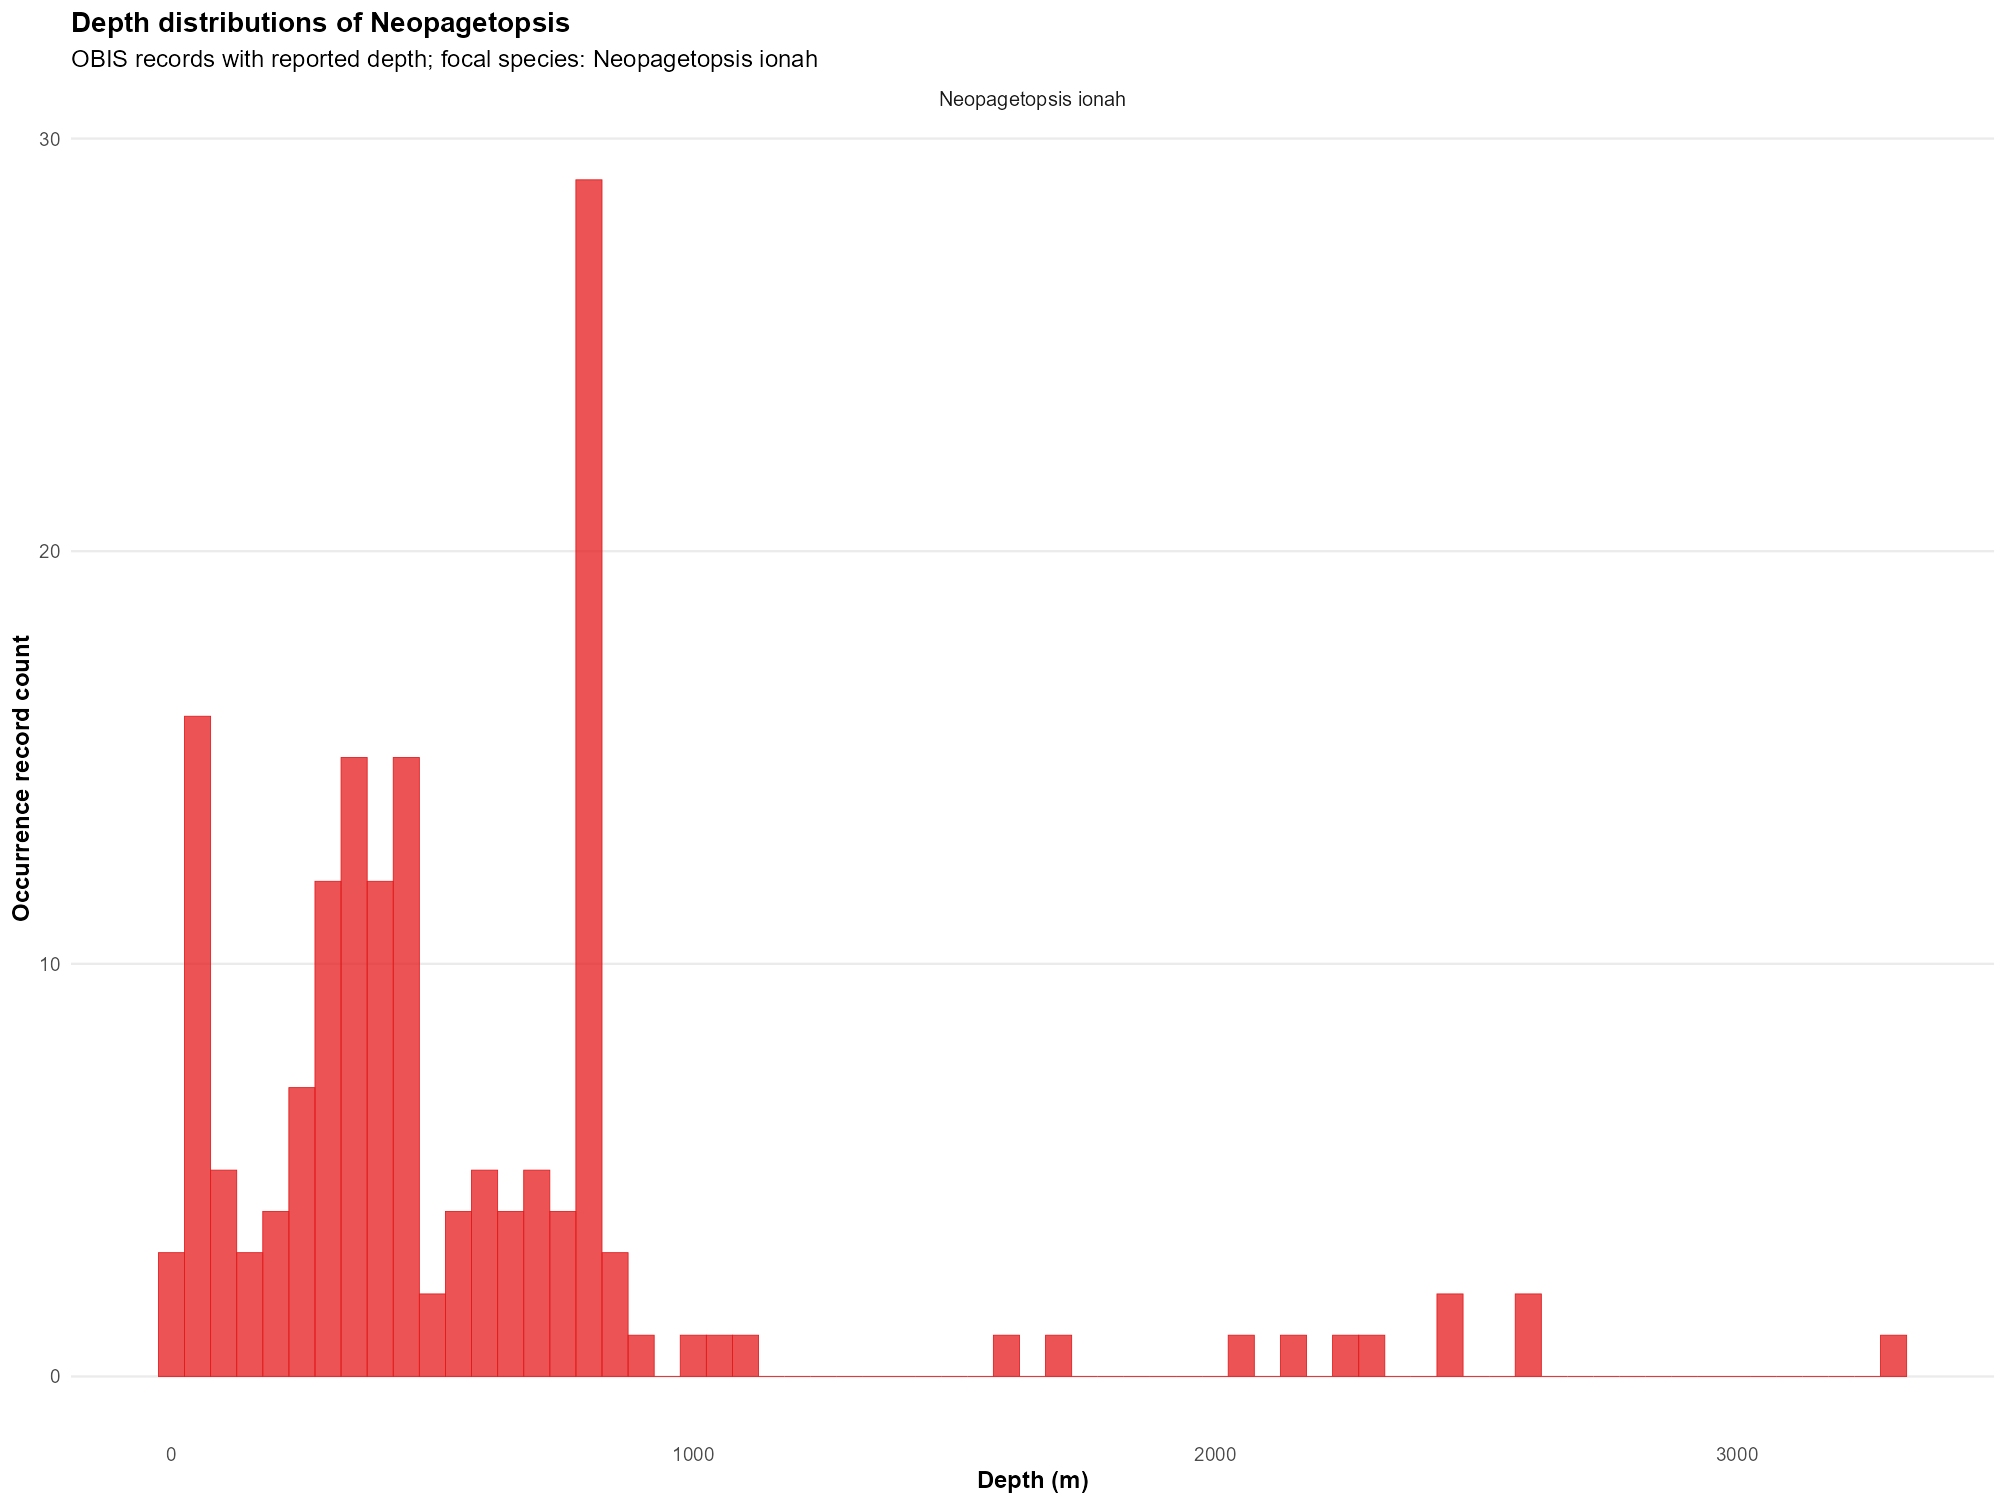

In [36]:
p_depth <- ggplot(
  data_filtered,
  aes(x = depth, fill = scientificName, color = scientificName)
) +
  geom_histogram(
    binwidth = 50,
    alpha = 0.75,
    linewidth = 0.2,
    position = "identity"
  ) +
  facet_wrap(~facet_label) +
  facet_wrap(~ species, scales = "free_y") +
  scale_fill_manual(values = my_colors) +
  scale_color_manual(values = my_colors) +
  theme_minimal(base_size = 12) +
  theme(
    legend.position = "none",
    strip.text = ggtext::element_markdown(size = 10),
    panel.grid.minor = element_blank(),
    panel.grid.major.x = element_blank(),
    axis.title = element_text(face = "bold"),
    plot.title = element_text(face = "bold", size = 14)
  ) +
  labs(
    title = paste0("Depth distributions of ", genusX),
    subtitle = paste0("OBIS records with reported depth; focal species: ", spX),
    x = "Depth (m)",
    y = "Occurrence record count"
  )

p_depth

## Output naming

The notebook creates an `output_basename` object from **family → genus → species**. Use it when saving plots, maps, HTML reports, or other outputs so every analysis is named consistently.

In [37]:
output_basename

[1] "Channichthyidae_Neopagetopsis_ionah_OBIS_depth_distribution_analysis"

# Save Report

In [38]:
# ============================================================
# EXPORT HTML REPORT
# ============================================================

# Notebook filename
notebook_file <- "OBIS_fish_depth_distribution_analysis.ipynb"

# Create reports directory
dir.create("reports", showWarnings = FALSE)

# Generate taxon-specific HTML filename
html_name <- paste0(output_basename, ".html")
html_file <- file.path("reports", html_name)

# Check notebook exists
if (!file.exists(notebook_file)) {
  stop("Notebook not found: ", notebook_file)
}

# Export using Python's nbconvert
export_log <- suppressWarnings(
  system2(
    "py",
    args = c(
      "-m", "nbconvert",
      "--to", "html",
      shQuote(normalizePath(notebook_file)),
      "--output", shQuote(html_name),
      "--output-dir", shQuote(normalizePath("reports")),
      "--TemplateExporter.exclude_input=True",
      "--TemplateExporter.exclude_input_prompt=True",
      "--TemplateExporter.exclude_output_prompt=True",
      "--TagRemovePreprocessor.enabled=True",
      "--TagRemovePreprocessor.remove_cell_tags=remove_cell"
    ),
    stdout = TRUE,
    stderr = TRUE
  )
)

# Display export messages
cat(paste(export_log, collapse = "\n"), "\n")

# Check for errors
exit_status <- attr(export_log, "status")

if (!is.null(exit_status) && exit_status != 0) {
  stop("HTML export failed with status: ", exit_status)
}

# Confirm report exists
if (!file.exists(html_file)) {
  stop("HTML report was not created: ", html_file)
}

cat("\nHTML report saved successfully:\n")
cat(normalizePath(html_file), "\n")

# Create GitHub Pages homepage
copied <- file.copy(
  from = html_file,
  to = "index.html",
  overwrite = TRUE
)

if (!copied) {
  warning("Report created, but index.html could not be updated.")
} else {
  cat("\nGitHub Pages index.html updated successfully.\n")
}

[NbConvertApp] Converting notebook C:\Users\LizzyMyers\GitHub\obis-fish-depth-distributions\OBIS_fish_depth_distribution_analysis.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 923651 bytes to C:\Users\LizzyMyers\GitHub\obis-fish-depth-distributions\reports\Channichthyidae_Neopagetopsis_ionah_OBIS_depth_distribution_analysis.html 

HTML report saved successfully:
C:\Users\LizzyMyers\GitHub\obis-fish-depth-distributions\reports\Channichthyidae_Neopagetopsis_ionah_OBIS_depth_distribution_analysis.html 

GitHub Pages index.html updated successfully.
